# 03D Real Business Cycle (RBC) Models: News Shocks and Expectations

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE)
[![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [ ]:
# === Environment Setup ===
import os
import sys
import math
import time
import random
import json
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from IPython.display import display, Markdown, Image

# Add scripts directory to path to import utility modules
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'scripts'))
try:
    from macro_utils import solve_qz
except ImportError:
    print("Warning: macro_utils not found. Please ensure scripts/macro_utils.py exists.")

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6), 'figure.dpi': 130,
                     'axes.titlesize': 'x-large', 'axes.labelsize': 'large',
                     'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium'})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=140, precision=4)
warnings.filterwarnings('ignore', category=FutureWarning)


Environment initialized for Advanced RBC model analysis.


# The Lens: Expectations and News Shocks

**What problem are we solving?**
Expectations about future productivity can move the economy today, even before productivity changes.

**Why this method?**
News shocks require extending the RBC state space to capture anticipated future changes and their effects on current decisions.

### Learning Objectives
* **Model** anticipated technology shocks with expanded state variables.
* **Compare** surprise and news shocks to interpret expectation-driven dynamics.
* **Explain** the investment-led boom mechanism from news shocks.

### Prerequisites
* **`04-Macro-Models/03C_RBC_Dynamics_and_Surprise_Shocks.ipynb`**: Surprise shock dynamics.
* **`04-Macro-Models/03B_RBC_Model_Solution.ipynb`**: Linearized solution and QZ decomposition.
* **`02-Numerical-Methods/01_Linear_Algebra.ipynb`**: Matrix methods.


# Table of Contents
* [The Lens: Expectations and News Shocks](#The-Lens:-Expectations-and-News-Shocks)
* [1. News Shock Dynamics](#1-news-shock-dynamics)
* [Interpretation: The Investment-Led Boom](#interpretation:-the-investment-led-boom)
* [Summary](#summary)


In [ ]:
# --- Base RBC model (from 03B) ---
class RBCModel:
    """
    Implements the canonical Real Business Cycle (RBC) model and solves it using
    the QZ decomposition (Klein's method).

    Reduced System Variables: [k_t, a_t, c_t]
    """
    def __init__(self, alpha=0.33, beta=0.99, delta=0.025, sigma=1.0, phi=1.0, rho_A=0.95, sigma_A=0.01, L_ss=1/3):
        self.alpha, self.beta, self.delta, self.sigma, self.phi = alpha, beta, delta, sigma, phi
        self.rho_A, self.sigma_A, self.L_ss_target = rho_A, sigma_A, L_ss
        self.ss = self._solve_steady_state()
        self.solution = self._solve_model()

    def _solve_steady_state(self):
        r_ss = 1 / self.beta - 1 + self.delta
        ky_ratio = self.alpha / r_ss

        L_ss = self.L_ss_target
        K_ss = ky_ratio ** (1 / (1 - self.alpha)) * L_ss
        Y_ss = K_ss ** self.alpha * L_ss ** (1 - self.alpha)
        I_ss = self.delta * K_ss
        C_ss = Y_ss - I_ss
        w_ss = (1 - self.alpha) * Y_ss / L_ss

        self.psi = w_ss / (C_ss ** self.sigma * L_ss ** self.phi)

        return pd.Series({'Y': Y_ss, 'K': K_ss, 'L': L_ss, 'C': C_ss, 'I': I_ss,
                          'w': w_ss, 'r': r_ss, 'psi': self.psi})

    def _solve_model(self):
        ss = self.ss
        alpha, beta, delta, sigma = self.alpha, self.beta, self.delta, self.sigma
        phi, rho_A = self.phi, self.rho_A
        r_ss = ss.r

        n_vars = 3
        n_states = 2

        AA = np.zeros((n_vars, n_vars))
        BB = np.zeros((n_vars, n_vars))

        denom = phi + alpha
        L_a = 1.0 / denom
        L_k = alpha / denom
        L_c = -sigma / denom

        Y_K = ss.Y / ss.K
        C_K = ss.C / ss.K

        y_a = 1 + (1 - alpha) * L_a
        y_k = alpha + (1 - alpha) * L_k
        y_c = (1 - alpha) * L_c

        AA[0, 0] = 1
        BB[0, 0] = (1 - delta) + Y_K * y_k
        BB[0, 1] = Y_K * y_a
        BB[0, 2] = Y_K * y_c - C_K

        r_a = 1 + (1 - alpha) * L_a
        r_k = (alpha - 1) + (1 - alpha) * L_k
        r_c = (1 - alpha) * L_c

        AA[1, 2] = sigma - beta * r_ss * r_c
        AA[1, 0] = -beta * r_ss * r_k
        AA[1, 1] = -beta * r_ss * r_a
        BB[1, 2] = sigma

        AA[2, 1] = 1
        BB[2, 1] = rho_A

        self.subs = {'L_a': L_a, 'L_k': L_k, 'L_c': L_c,
                     'y_a': y_a, 'y_k': y_k, 'y_c': y_c,
                     'r_a': r_a, 'r_k': r_k, 'r_c': r_c}

        return solve_qz(AA, BB, n_states)

    def reconstruct_variables(self, k, a, c):
        s = self.subs
        l = s['L_a'] * a + s['L_k'] * k + s['L_c'] * c
        y = s['y_a'] * a + s['y_k'] * k + s['y_c'] * c
        i = (self.ss.Y / self.ss.I) * y - (self.ss.C / self.ss.I) * c
        w = y - l
        r = s['r_a'] * a + s['r_k'] * k + s['r_c'] * c
        return l, y, i, w, r

rbc = RBCModel()
print("> **Note:** Base RBC model initialized for dynamics.")

## 1. News Shock Dynamics

We compare a surprise shock at $t=0$ with a news shock announced at $t=0$ that materializes later.


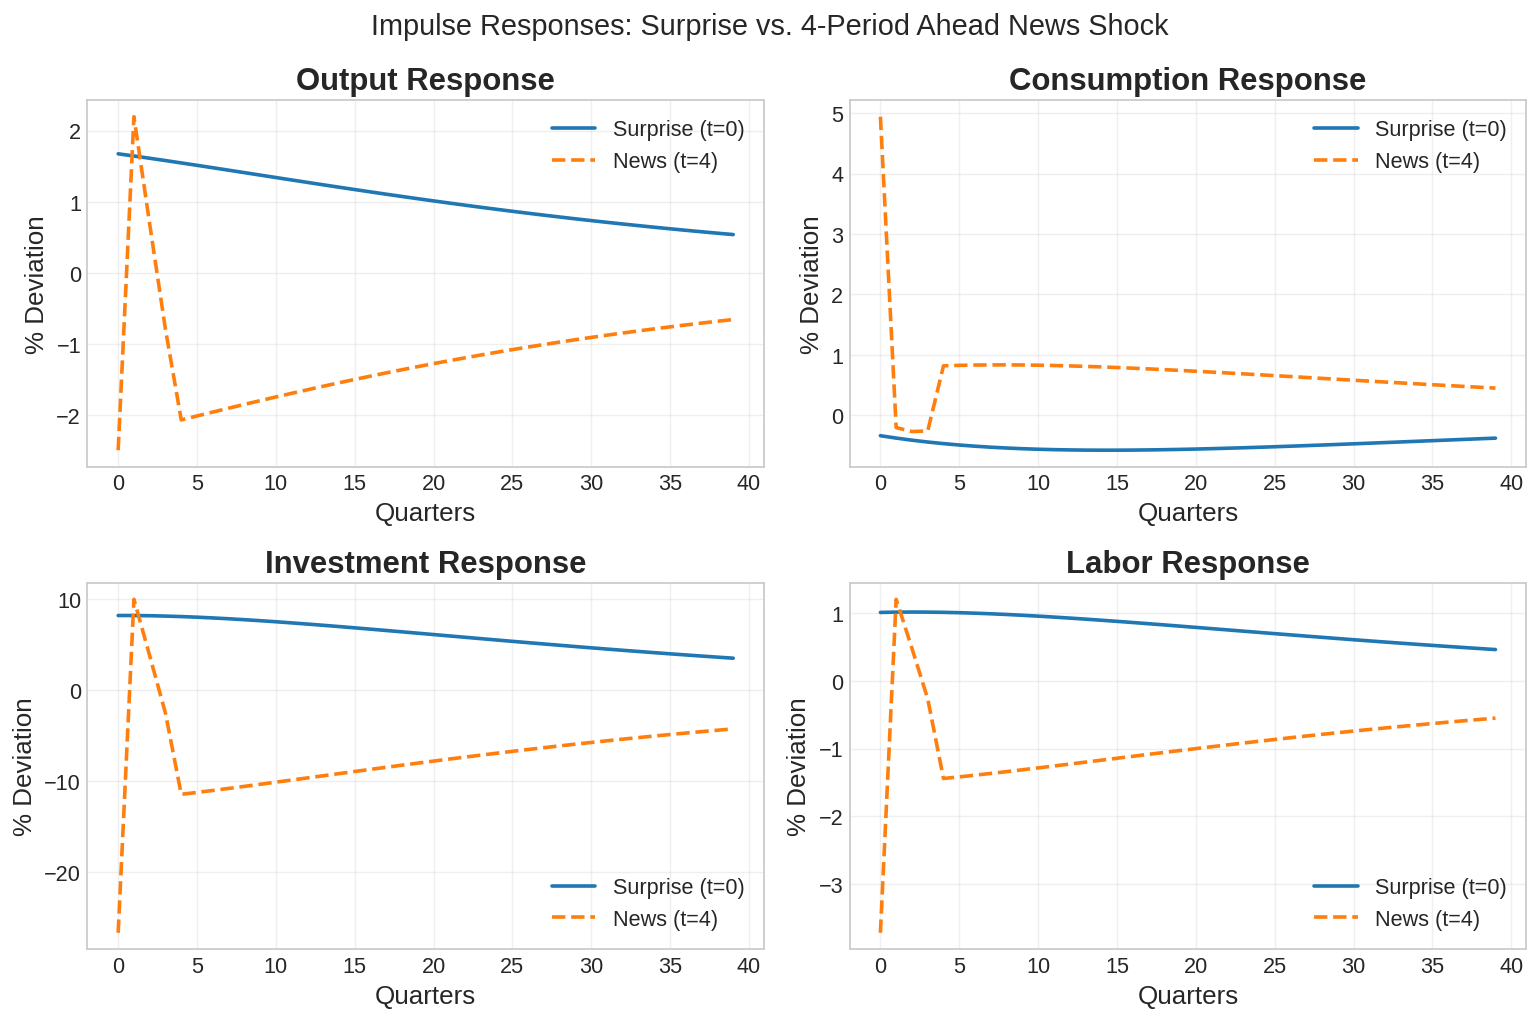

In [3]:
class RBCNewsModel(RBCModel):
    """
    Extends the RBC model to include 'news' states for anticipated shocks.
    State vector expands to: [k, a, c, n1, n2, n3, n4]
    """
    def _solve_model(self):
        ss = self.ss
        alpha, beta, delta, sigma = self.alpha, self.beta, self.delta, self.sigma
        phi, rho_A = self.phi, self.rho_A
        r_ss = ss.r
        
        n_vars = 3 + 4 # 3 core + 4 news
        n_states = 2 + 4 # k, a + n1..n4
        
        AA = np.zeros((n_vars, n_vars))
        BB = np.zeros((n_vars, n_vars))
        
        # Reuse substitution constants
        denom = phi + alpha
        L_a, L_k, L_c = 1.0/denom, alpha/denom, -sigma/denom
        y_a, y_k, y_c = 1+(1-alpha)*L_a, alpha+(1-alpha)*L_k, (1-alpha)*L_c
        r_a, r_k, r_c = 1+(1-alpha)*L_a, (alpha-1)+(1-alpha)*L_k, (1-alpha)*L_c
        
        Y_K = ss.Y / ss.K
        C_K = ss.C / ss.K
        
        # --- Original Blocks ---
        # 1. Resource (k_{t+1})
        AA[0, 0] = 1
        BB[0, 0] = (1-delta) + Y_K * y_k
        BB[0, 1] = Y_K * y_a
        BB[0, 2] = Y_K * y_c - C_K
        
        # 2. Euler (c_{t+1})
        AA[1, 2] = sigma - beta * r_ss * r_c
        AA[1, 0] = -beta * r_ss * r_k
        AA[1, 1] = -beta * r_ss * r_a
        BB[1, 2] = sigma
        
        # 3. Technology (a_{t+1} depends on a_t AND n1_t)
        AA[2, 1] = 1
        BB[2, 1] = rho_A
        BB[2, 3] = 1 # n1 is index 3
        
        # --- News Blocks ---
        # Indices: k=0, a=1, c=2, n1=3, n2=4, n3=5, n4=6
        # n1_{t+1} = n2_t
        AA[3, 3] = 1; BB[3, 4] = 1
        AA[4, 4] = 1; BB[4, 5] = 1
        AA[5, 5] = 1; BB[5, 6] = 1
        AA[6, 6] = 1 # n4_{t+1} = 0 (persistent)
        
        self.subs = {'L_a': L_a, 'L_k': L_k, 'L_c': L_c,
                     'y_a': y_a, 'y_k': y_k, 'y_c': y_c,
                     'r_a': r_a, 'r_k': r_k, 'r_c': r_c}
        
        return solve_qz(AA, BB, n_states)


# --- Simulation Logic ---
def simulate_rbc_scenarios(model_base, model_news, T=40):
    # 1. Surprise Shock (Basic Model)
    # State: [k, a]
    state = np.zeros(2) 
    state[1] = 0.01
    
    # Storage for all variables: k, a, c, l, y, i
    # We will store them in a dict of lists
    history_surp = {'y': [], 'c': [], 'i': [], 'l': []}
    
    P = model_base.solution['Policy']
    Q = model_base.solution['Transition']

    for t in range(T):
        # Get control c
        c = (P @ state)[0]
        k, a = state[0], state[1]
        
        # Reconstruct others
        l, y, i, w, r = model_base.reconstruct_variables(k, a, c)
        
        history_surp['y'].append(y)
        history_surp['c'].append(c)
        history_surp['i'].append(i)
        history_surp['l'].append(l)
        
        state = Q @ state

    # 2. News Shock (News Model)
    # State: [k, a, n1, n2, n3, n4]
    state_n = np.zeros(6)
    state_n[5] = 0.01 # n4 shock
    
    history_news = {'y': [], 'c': [], 'i': [], 'l': []}
    
    P_n = model_news.solution['Policy']
    Q_n = model_news.solution['Transition']

    for t in range(T):
        c = (P_n @ state_n)[0]
        k, a = state_n[0], state_n[1]
        
        l, y, i, w, r = model_news.reconstruct_variables(k, a, c)
        
        history_news['y'].append(y)
        history_news['c'].append(c)
        history_news['i'].append(i)
        history_news['l'].append(l)
        
        state_n = Q_n @ state_n

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    vars_list = ['Output', 'Consumption', 'Investment', 'Labor']
    keys = ['y', 'c', 'i', 'l']

    for ax, var, key in zip(axes.flatten(), vars_list, keys):
        ax.plot(np.array(history_surp[key])*100, label='Surprise (t=0)', linewidth=2)
        ax.plot(np.array(history_news[key])*100, linestyle='--', label='News (t=4)', linewidth=2)
        ax.set_title(f'{var} Response', fontweight='bold')
        ax.set_xlabel('Quarters')
        ax.set_ylabel('% Deviation')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Impulse Responses: Surprise vs. 4-Period Ahead News Shock', fontsize=16)
    plt.tight_layout()
    plt.show()

simulate_rbc_scenarios(rbc, RBCNewsModel())

### Interpretation: The Investment-Led Boom

Notice the striking difference in the "News" simulation:

1.  **Consumption:** Rises *immediately* upon hearing the news, even though productivity hasn't changed yet. Agents feel wealthier.
2.  **Labor & Investment:** Also rise immediately. Why? To smooth consumption, agents want to save for the future. But they also want to consume more now. To achieve both, they work harder today to build up capital so that when the productivity boom hits, they have a large capital stock to take advantage of it.

This **co-movement** of C, I, and L in response to news is a key success of the model.

# Summary

In this chapter, we have:

1.  **Formalized** the RBC model as a dynamic system of optimizing agents.
2.  **Solved** the model using modern methods (QZ decomposition), handling the complex issue of state variable transformation automatically.
3.  **Discovered** that the model can generate realistic "investment-led booms" through news shocks, a feature that pure surprise-shock models lack.

The RBC model remains the foundation of modern macro. Even as we add frictions (sticky prices, financial constraints) to build New Keynesian models, the core transmission mechanism—intertemporal substitution and capital accumulation—remains identical to what we built here.